## Fix netlist generation and visualization
Authored 11/07/2024

Validate changes to netlist generation and visualization code. 
Create 3 test cases to show that code works correctly:
1. 2-element voltage divider
2. 3-element chain of transistors
3. 3 x 3 grid with periodic boundary conditions

In [1]:
%reload_ext autoreload
%autoreload 2

import PySpice.Spice.Xyce
import PySpice.Spice.Xyce.Server
from helpers import *
from spice_net import *

import numpy as np
import networkx as nx
import tqdm
import json
import matplotlib
import matplotlib.pyplot as plt

import PySpice
PySpice.Spice.Simulation.CircuitSimulator.DEFAULT_SIMULATOR = "ngspice-shared" 
import PySpice.Spice.NgSpice.Server
PySpice.Spice.NgSpice.Server.SpiceServer.SPICE_COMMAND = 'ngspice'
PySpice.Spice.Xyce.Server.XyceServer.XYCE_COMMAND = '/Users/lancemathias/XyceInstall/Serial/bin/Xyce'

## Validating input graph vs. netlist vs. visualizations

In [2]:
def init_model_xor(name, cls, seed, eta=0.5):
    np.random.seed(seed)

    grid_size = 4

    grid_graph = nx.grid_graph([grid_size, grid_size], periodic=True)
    # relabel nodes to be ints
    grid_graph = nx.convert_node_labels_to_integers(grid_graph, first_label=1, ordering='sorted')
    grid_graph.add_node(0)

    # grid_graph.add_node((-1, -1))

    for e in grid_graph.edges:
        # grid_graph[e[0]][e[1]]['weight'] = 0.5                           # init to max value
        grid_graph[e[0]][e[1]]['weight'] = np.random.uniform(0.0, 5.)       # random value

    node_cfg = (np.array([[6, 0], [8, 0], [16, 0], [14, 0]]), np.array([[11, 1]]))

    return cls(name, con_graph=grid_graph, node_cfg=node_cfg, solver='ngspice-subprocess', epsilon=1e-16)
    # TODO: look for checkpoints and load them if found

# XOR task
def init_model_xor_old(name, cls, seed, eta=0.5):
    np.random.seed(seed)

    grid_graph = nx.grid_graph([4, 4], periodic=True)
    grid_graph.add_node((-1, -1))

    for e in grid_graph.edges:
        grid_graph[e[0]][e[1]]["weight"] = np.random.uniform(0, 1)  # random init
        # grid_graph[e[0]][e[1]]['weight'] = 5                           # init to max value

    grid_graph = nx.convert_node_labels_to_integers(grid_graph, first_label=0, ordering="default")
    node_cfg = (np.array([[5, 16], [7, 16], [13, 16], [15, 16]]), np.array([[10, 0]])) 
    # node_cfg = (np.array([[5, 16], [7, 16], [13, 16], [15, 16]]), np.array([[10, 0]])) # TODO: old line, need to rename nodes?
    return cls(name, con_graph=grid_graph, node_cfg=node_cfg, solver='ngspice-subprocess', epsilon=1e-16)

In [225]:
grid_old = nx.grid_graph([4, 4], periodic=True)
grid_old.add_node((-1, -1))

for e in grid_old.edges:
    grid_old[e[0]][e[1]]["weight"] = np.random.uniform(0, 1)  # random init
    # grid_graph[e[0]][e[1]]['weight'] = 5                           # init to max value

node_cfg_old = (np.array([[5, 16], [7, 16], [13, 16], [15, 16]]), np.array([[10, 0]])) 


In [226]:
grid_old = nx.convert_node_labels_to_integers(grid_old, first_label=0, ordering="default")
net_old = TransistorNetwork("old", grid_old, node_cfg_old, 'ngspice-subprocess')

In [227]:
G_old = graph_from_netlist(net_old)

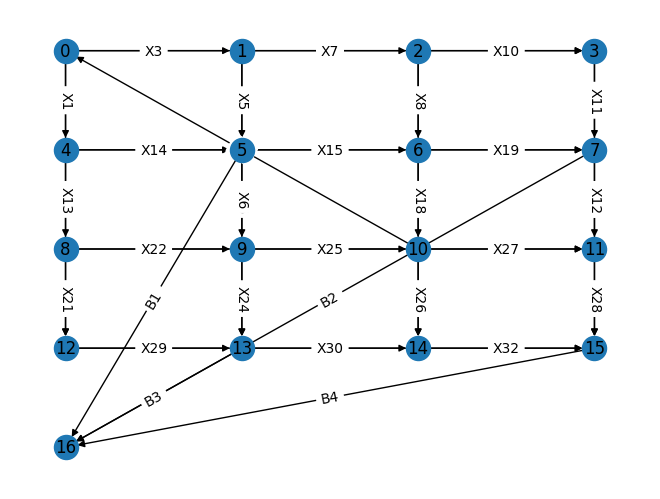

In [228]:
# pos = nx.kamada_kawai_layout(G)
pos = {i: ((i) % 4, -((i) // 4)) for i in G_old.nodes}
nx.draw(G_old, pos, with_labels=True)
nx.draw_networkx_edge_labels(G_old, pos, edge_labels={(u, v): G_old.edges[u, v]["name"] for u, v in G_old.edges})
plt.show()

### Example netlist generation code

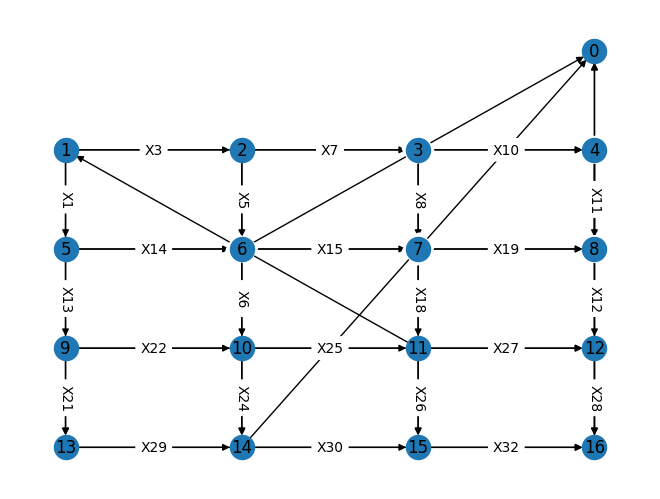

In [229]:
net_test = init_model_xor("test", TransistorNetwork, 0)
G_test = graph_from_netlist(net_test)

pos = {i: ((i-1) % 4, -((i-1) // 4)) for i in G_test.nodes}
nx.draw(G_test, pos, with_labels=True)
nx.draw_networkx_edge_labels(G_test, pos, edge_labels={(u, v): G_test.edges[u, v]["name"] for u, v in G_test.edges})
plt.show()

In [230]:
seed = 0
np.random.seed(seed)

grid_size = 4

grid_graph = nx.grid_graph([grid_size, grid_size], periodic=True)
# relabel nodes to be ints
grid_graph = nx.convert_node_labels_to_integers(grid_graph, first_label=1, ordering='sorted')
grid_graph.add_node(0)

# grid_graph.add_node((-1, -1))

for e in grid_graph.edges:
    # grid_graph[e[0]][e[1]]['weight'] = 0.5                           # init to max value
    grid_graph[e[0]][e[1]]['weight'] = np.random.uniform(0.1, 0.9)       # random value

node_cfg = (np.array([[6, 0], [8, 0], [16, 0], [14, 0]]), np.array([[11, 1]]))

net = TransistorNetwork('test', grid_graph, node_cfg, 'ngspice-subprocess')

In [231]:
def graph_from_netlist(net: TransistorNetwork):
    G = nx.DiGraph()
    G.add_nodes_from(net.node_names)

    for e in net.elements:
        u, v = e.node_names
        G.add_edge(u, v, name=e.name, PREFIX=e.PREFIX)
    
    # remove nodes that we added for "behind-the-scenes" hacking
    G.remove_node("index")
    G = nx.relabel_nodes(G, int, copy=False)
    return G

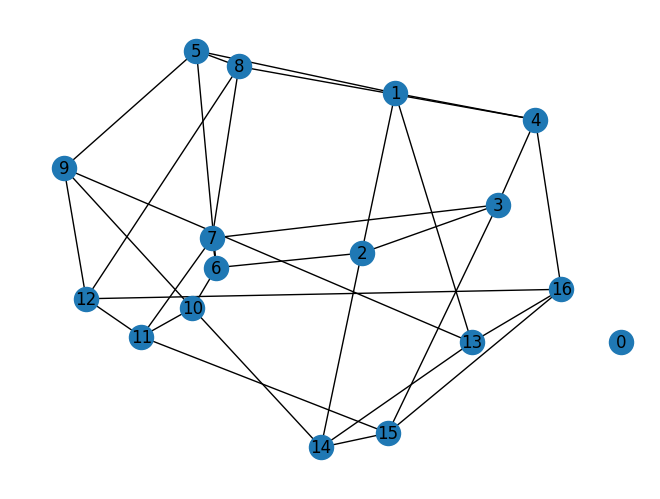

In [232]:
pos = nx.kamada_kawai_layout(grid_graph)
nx.draw(grid_graph, pos, with_labels=True)
plt.show()

In [233]:
G = graph_from_netlist(net)

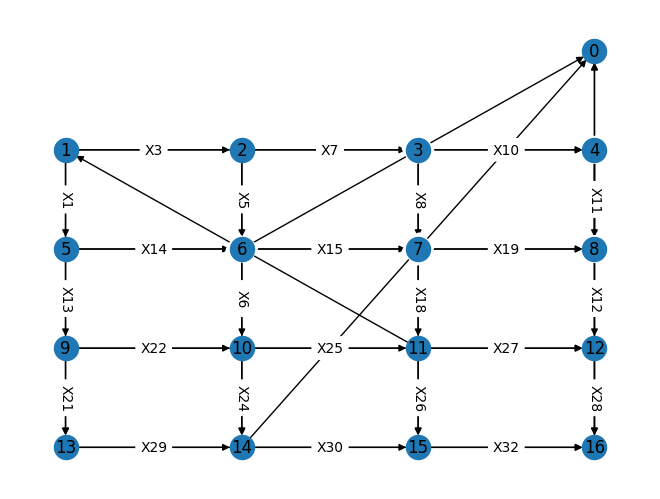

In [234]:
# pos = nx.kamada_kawai_layout(G)
pos = {i: ((i-1) % grid_size, -((i-1) // grid_size)) for i in grid_graph.nodes}
nx.draw(G, pos, with_labels=True)
nx.draw_networkx_edge_labels(G, pos, edge_labels={(u, v): G.edges[u, v]["name"] for u, v in G.edges})
plt.show()

In [235]:
G.nodes

NodeView((0, 6, 8, 16, 14, 11, 1, 5, 13, 2, 4, 3, 7, 15, 9, 10, 12))

In [236]:
graph_str = json.dumps(nx.node_link_data(G))

gg = nx.readwrite.json_graph.node_link_graph(json.loads(graph_str))

In [237]:
print(json.dumps(json.loads(graph_str), indent=4))

{
    "directed": true,
    "multigraph": false,
    "graph": {},
    "nodes": [
        {
            "id": 0
        },
        {
            "id": 6
        },
        {
            "id": 8
        },
        {
            "id": 16
        },
        {
            "id": 14
        },
        {
            "id": 11
        },
        {
            "id": 1
        },
        {
            "id": 5
        },
        {
            "id": 13
        },
        {
            "id": 2
        },
        {
            "id": 4
        },
        {
            "id": 3
        },
        {
            "id": 7
        },
        {
            "id": 15
        },
        {
            "id": 9
        },
        {
            "id": 10
        },
        {
            "id": 12
        }
    ],
    "links": [
        {
            "name": "B1",
            "PREFIX": "B",
            "source": 6,
            "target": 0
        },
        {
            "name": "X17",
            "PREFIX": "X",
       

In [238]:
gg.nodes

NodeView((0, 6, 8, 16, 14, 11, 1, 5, 13, 2, 4, 3, 7, 15, 9, 10, 12))

### Simple Voltage Divider

In [243]:
vd_graph = nx.from_numpy_array(np.array([[0, 1, 0], [1, 0, 1], [0, 1, 0]]))
vd_node_cfg=(np.array([[2, 0]]), np.array([[1, 0]]))
vd_net = TransistorNetwork("voltage divider", vd_graph, vd_node_cfg, 'ngspice-subprocess')

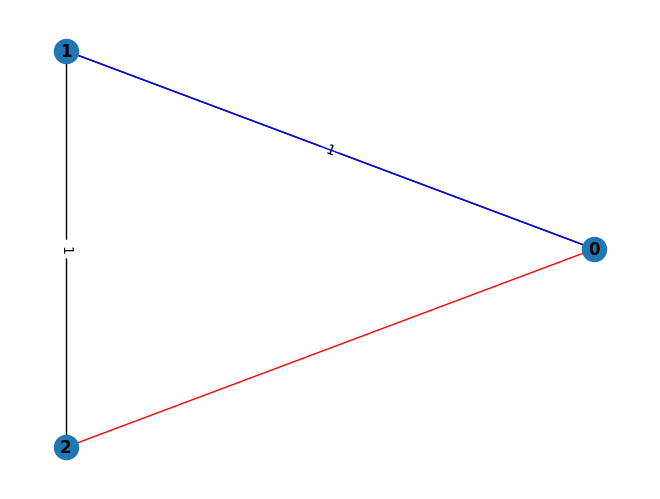

In [245]:
# Draw with edge labels
vd_graph_vis = vd_graph.copy()
vd_graph_vis.add_edges_from(vd_node_cfg[0])
vd_graph_vis.add_edges_from(vd_node_cfg[1])
pos = nx.kamada_kawai_layout(vd_graph_vis)
nx.draw(vd_graph, pos, with_labels=True, font_weight='bold')
edge_labels = nx.get_edge_attributes(vd_graph, 'weight')
nx.draw_networkx_edge_labels(vd_graph, pos, edge_labels=edge_labels)

nx.draw_networkx_edges(vd_graph, pos, edgelist=vd_node_cfg[0], edge_color='r')
nx.draw_networkx_edges(vd_graph, pos, edgelist=vd_node_cfg[1], edge_color='b')


In [246]:
print(vd_net)

.title voltage divider
.subckt transistor_edge t_D t_S vgs=0.5
V1 t_G t_S {vgs}
R1 t_D t_S 1e+16
M1 t_D t_G t_S t_S Ideal
.ends transistor_edge
B1 2 0
B2 1 0
Vindex index 0 1
X1 0 1 transistor_edge vg=1
X2 1 2 transistor_edge vg=1
.model Ideal NMOS (level=1)
.model NMOS NMOS (level=1)



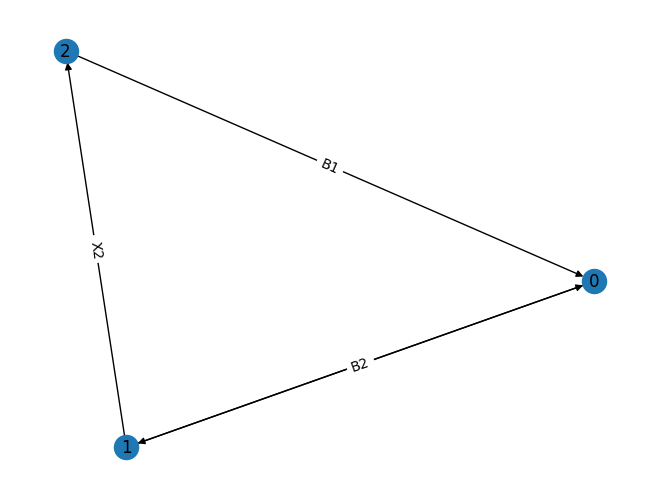

In [247]:
G_vd = graph_from_netlist(vd_net)
pos = nx.kamada_kawai_layout(G_vd)
nx.draw(G_vd, pos, with_labels=True)
nx.draw_networkx_edge_labels(G_vd, pos, edge_labels={(u, v): G_vd.edges[u, v]["name"] for u, v in G_vd.edges})
plt.show()

### Three Resistor Chain

In [248]:
G_chain = nx.DiGraph()
G_chain.add_nodes_from([0, 1, 2, 3])
G_chain.add_edges_from([(0, 1), (1, 2), (2, 3)])

for u, v in G_chain.edges:
    G_chain.edges[u, v]['weight'] = np.random.uniform(0.0, 1.) 

node_cfg_chain=(np.array([[3, 0]]), np.array([[2, 1]]))
chain_net = TransistorNetworkGroundref("three chain", G_chain, node_cfg_chain, 'ngspice-subprocess')

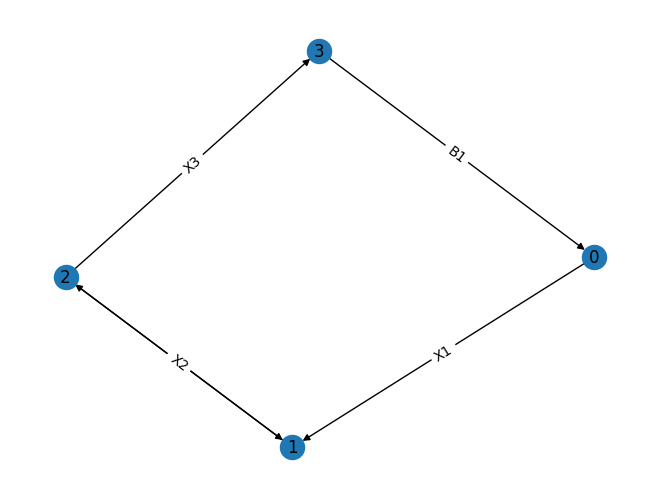

In [249]:
G_chain_net = graph_from_netlist(chain_net)
pos = nx.kamada_kawai_layout(G_chain_net)
nx.draw(G_chain_net, pos, with_labels=True)
nx.draw_networkx_edge_labels(G_chain_net, pos, edge_labels={(u, v): G_chain_net.edges[u, v]["name"] for u, v in G_chain_net.edges})
plt.show()

In [255]:
print(chain_net)

.title three chain
.include /Users/lancemathias/Projects/circuit_sim/experiments/my_lib.lib
.subckt transistor_edge_groundref t_D t_S vg=2.5
V1 t_G t_S {vg}
X1 t_D t_G t_S 0 0 1106
.ends transistor_edge_groundref
B1 3 0
B2 2 1
Vindex index 0 1
X1 0 1 transistor_edge_groundref vg=0.45615033221654855
X2 1 2 transistor_edge_groundref vg=0.5684339488686485
X3 2 3 transistor_edge_groundref vg=0.018789800436355142



In [250]:
from os import path
xor_data = np.load(path.join('../data', "xor_train_data.npz"))


In [251]:
in_data = np.array([[.2], [.1]])
out_data = np.array([[0.1], [0.075]])

In [252]:
xor_data["inputs"], in_data

(array([[0.11, 0.33, 0.  , 0.  ],
        [0.11, 0.33, 0.  , 0.45],
        [0.11, 0.33, 0.45, 0.  ],
        [0.11, 0.33, 0.45, 0.45]]),
 array([[0.2],
        [0.1]]))

In [253]:
xor_data["outputs"], out_data

(array([[-0.   ],
        [-0.087],
        [-0.087],
        [-0.   ]]),
 array([[0.1  ],
        [0.075]]))

In [254]:
N_ITERS = 500
NUDGE_FACTOR = 0.9
LEARNING_RATE = (1e-4)/(100 * 0.33 * 22e-6)
print(LEARNING_RATE)

0.13774104683195593


In [192]:
e1, e2 = [], []
for E in chain_net.edges:
    a, b = list(map(int, E.edge.node_names[:2]))
    e1.append(a)
    e2.append(b)

In [193]:
preds = []
labels = []

for j in tqdm.trange(N_ITERS, leave=False):
    idx = np.random.randint(0, 2)
    
    chain_net, pred, update = step_network(
        chain_net,
        in_data[idx],
        out_data[idx],
        e1, 
        e2,
        eta=NUDGE_FACTOR,
        gamma=LEARNING_RATE,
    )
    labels.append(out_data[idx].item())
    preds.append(pred.item())

  0%|          | 0/500 [00:00<?, ?it/s]

In [194]:
MSE = np.abs(np.array(preds) - np.array(labels))**2

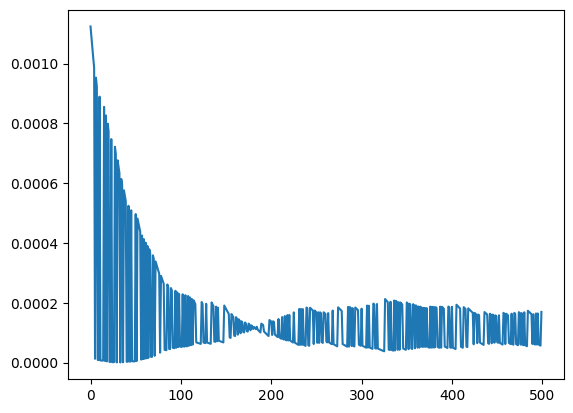

In [195]:
plt.plot(MSE)
plt.show()

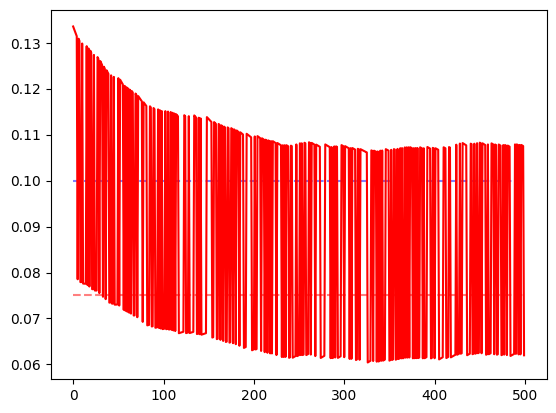

In [196]:
# plt.plot(preds[::2], c='b')
plt.plot(np.ones_like(preds)*out_data[0][0], '--', c='b', alpha=0.5)
# plt.plot(preds[1::2], c='r')
plt.plot(preds, c='r')
plt.plot(np.ones_like(preds)*out_data[1][0], '--', c='r', alpha=.5)
plt.show()

In [197]:
preds[-5:]

[0.06219343842966962,
 0.10774862697984589,
 0.10762855461748833,
 0.10751038754657372,
 0.061991064234075854]

In [198]:
labels[-5:]

[0.075, 0.1, 0.1, 0.1, 0.075]

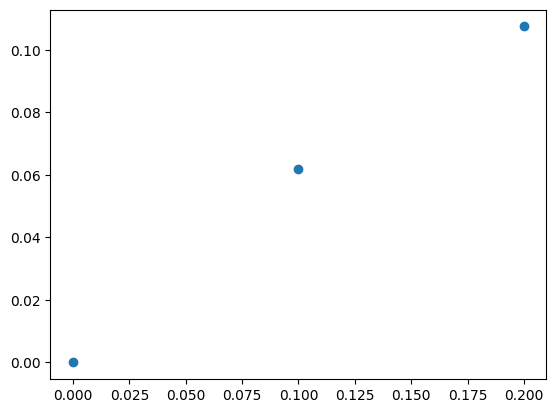

In [203]:
plt.scatter([0, in_data[0].item(), in_data[1].item()], [0, preds[-2], preds[-1]])

## Ensuring the network can train correctly

#### Finding good nonlinear training examples

In [2]:
# 3 node chain
G_chain = nx.DiGraph()
G_chain.add_nodes_from([0, 1, 2, 3])
G_chain.add_edges_from([(0, 1), (1, 2), (2, 3)])

# need to ensure starting VG isn't undefined,
# but will be overwitten in next step
# sentinel value for now
for u, v in G_chain.edges:
    G_chain.edges[u, v]['weight'] = -1 

node_cfg_chain=(np.array([[3, 0]]), np.array([[2, 1]]))

chain_net = TransistorNetworkGroundref("three chain", G_chain, node_cfg_chain, 'ngspice-subprocess')

In [3]:
print(chain_net)

.title three chain
.include /Users/lancemathias/Projects/circuit_sim/experiments/my_lib.lib
.subckt transistor_edge_groundref t_D t_S val=2.5
V1 t_G t_S {val}
X1 t_D t_G t_S 0 0 1106
.ends transistor_edge_groundref
B1 3 0
B2 2 1
Vindex index 0 1
X1 0 1 transistor_edge_groundref val=-1
X2 1 2 transistor_edge_groundref val=-1
X3 2 3 transistor_edge_groundref val=-1



In [4]:
# experimental setup
rng_seed = 0
N_TRIALS = 10000

v_sweep_vals = np.linspace(0, 1, 20)

In [5]:
# measure degree of nonlinearity of the data (thanks GPT)
import numpy as np
from sklearn.linear_model import LinearRegression

def quantify_nonlinearity(values):
    x = np.arange(len(values)).reshape(-1, 1)  # Use indices as x-values
    y = np.array(values)
    linear_model = LinearRegression()
    linear_model.fit(x, y)
    y_pred = linear_model.predict(x)

    mse = np.mean((y - y_pred) ** 2)
    return mse

In [13]:
# outputs to record
vg_vals = []
mse_vals = []

In [15]:
np.random.seed(rng_seed)

for _ in tqdm.trange(N_TRIALS):
    for e in chain_net.edges:
        # parameter name needs to be consistent with edge type
        e.edge.parameters['vg'] = np.random.uniform(0, 5)

        chain_net._prepare_simulation(v_sweep_vals.reshape(-1, 1))
        res = chain_net._run_simulation()

    # hardcoded based on handmade network's output config
    out_vals = res.nodes['2'] - res.nodes['1']

    # save results
    vg_vals.append([e.edge.parameters['vg'] for e in chain_net.edges])
    mse_vals.append(quantify_nonlinearity(out_vals))

  2%|▏         | 152/10000 [00:07<07:46, 21.09it/s]


KeyboardInterrupt: 

In [49]:
vg_vals = [[.88, .35, 1.]]
mse_vals = [0]

#### Examine and plot most interesting examples

In [50]:
# sort trials in descending order of nonlinearity
sorted_mse_vals, sorted_vg_vals = zip(*sorted(zip(mse_vals, vg_vals), reverse=True))

AssertionError: MSE mismatch: got 1.5671680241161494e-05, expected 0

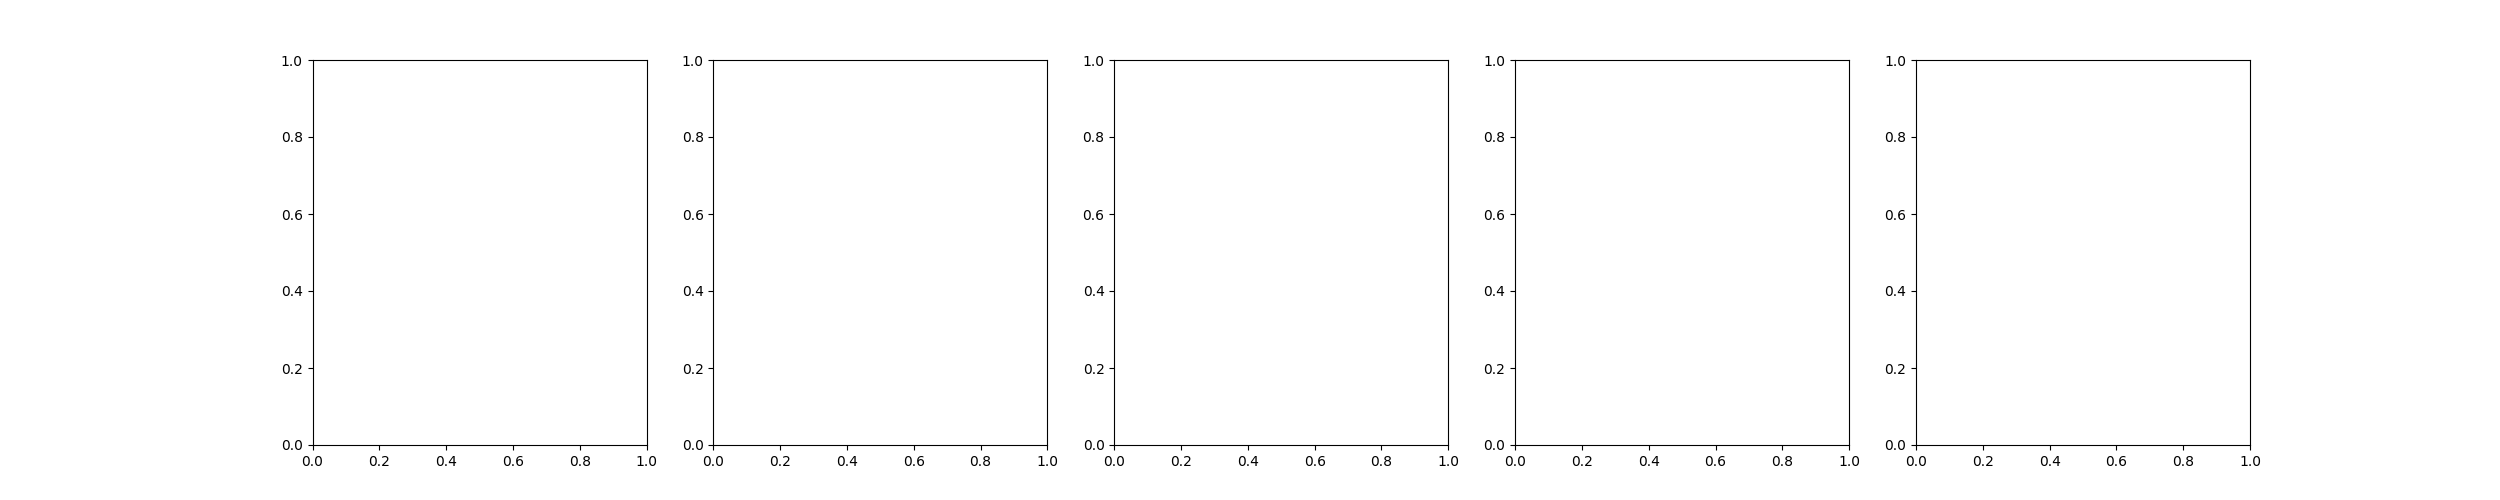

In [51]:
# plot 5 most nonlinear trials
fig, axs = plt.subplots(1, 5, figsize=(25, 5))

for ax, vg_vals, mse in zip(axs, sorted_vg_vals[:5], sorted_mse_vals[:5]):
    # re-simulate with given configs
    for e, vg in zip(chain_net.edges, vg_vals):
        e.edge.parameters['vg'] = vg

    chain_net._prepare_simulation(v_sweep_vals.reshape(-1, 1))
    res = chain_net._run_simulation()

    # hardcoded based on handmade network's output config
    out_vals = res.nodes['2'] - res.nodes['1']

    # re-compute MSE and ensure it matches
    assert np.isclose(quantify_nonlinearity(out_vals), mse), f"MSE mismatch: got {quantify_nonlinearity(out_vals)}, expected {mse}"

    ax.plot(v_sweep_vals, out_vals)
    ax.set_title(f"VG: {[f'{v:.2f}' for v in vg_vals]} MSE: {mse:.5f}")
    
fig.suptitle("Most Nonlinear Trials")
plt.show()

In [52]:
plt.hist(mse_vals, bins=20, alpha=0.7)
plt.xlabel("MSE")
plt.ylabel("Frequency")
plt.title("Distribution of nonlinearity in output")

Text(0.5, 1.0, 'Distribution of nonlinearity in output')

In [53]:
n_plot_dissimilar = 15

In [54]:
# find n dissimilar trials
# index into sorted_vg_vals or mse_vals to get the trials or metrics
chosen_idxs = [0]


def similarity_score(v1, v2):
    v1 = np.array(v1)
    v2 = np.array(v2)
    v1_norm = v1 / v1.max()
    v2_norm = v2 / v2.max()
    return np.linalg.norm(v1_norm - v2_norm)


while len(chosen_idxs) < n_plot_dissimilar:
    # find the most dissimilar trial to the chosen ones
    most_dissimilar_idx = np.argmax(
        [
            min(
                [
                    similarity_score(sorted_vg_vals[i], sorted_vg_vals[j])
                    for j in chosen_idxs
                ]
            )
            for i in range(len(sorted_vg_vals))
        ]
    )

    # add the most dissimilar trial
    chosen_idxs.append(most_dissimilar_idx)

AssertionError: MSE mismatch: got 0.0019193214221514322, expected 0

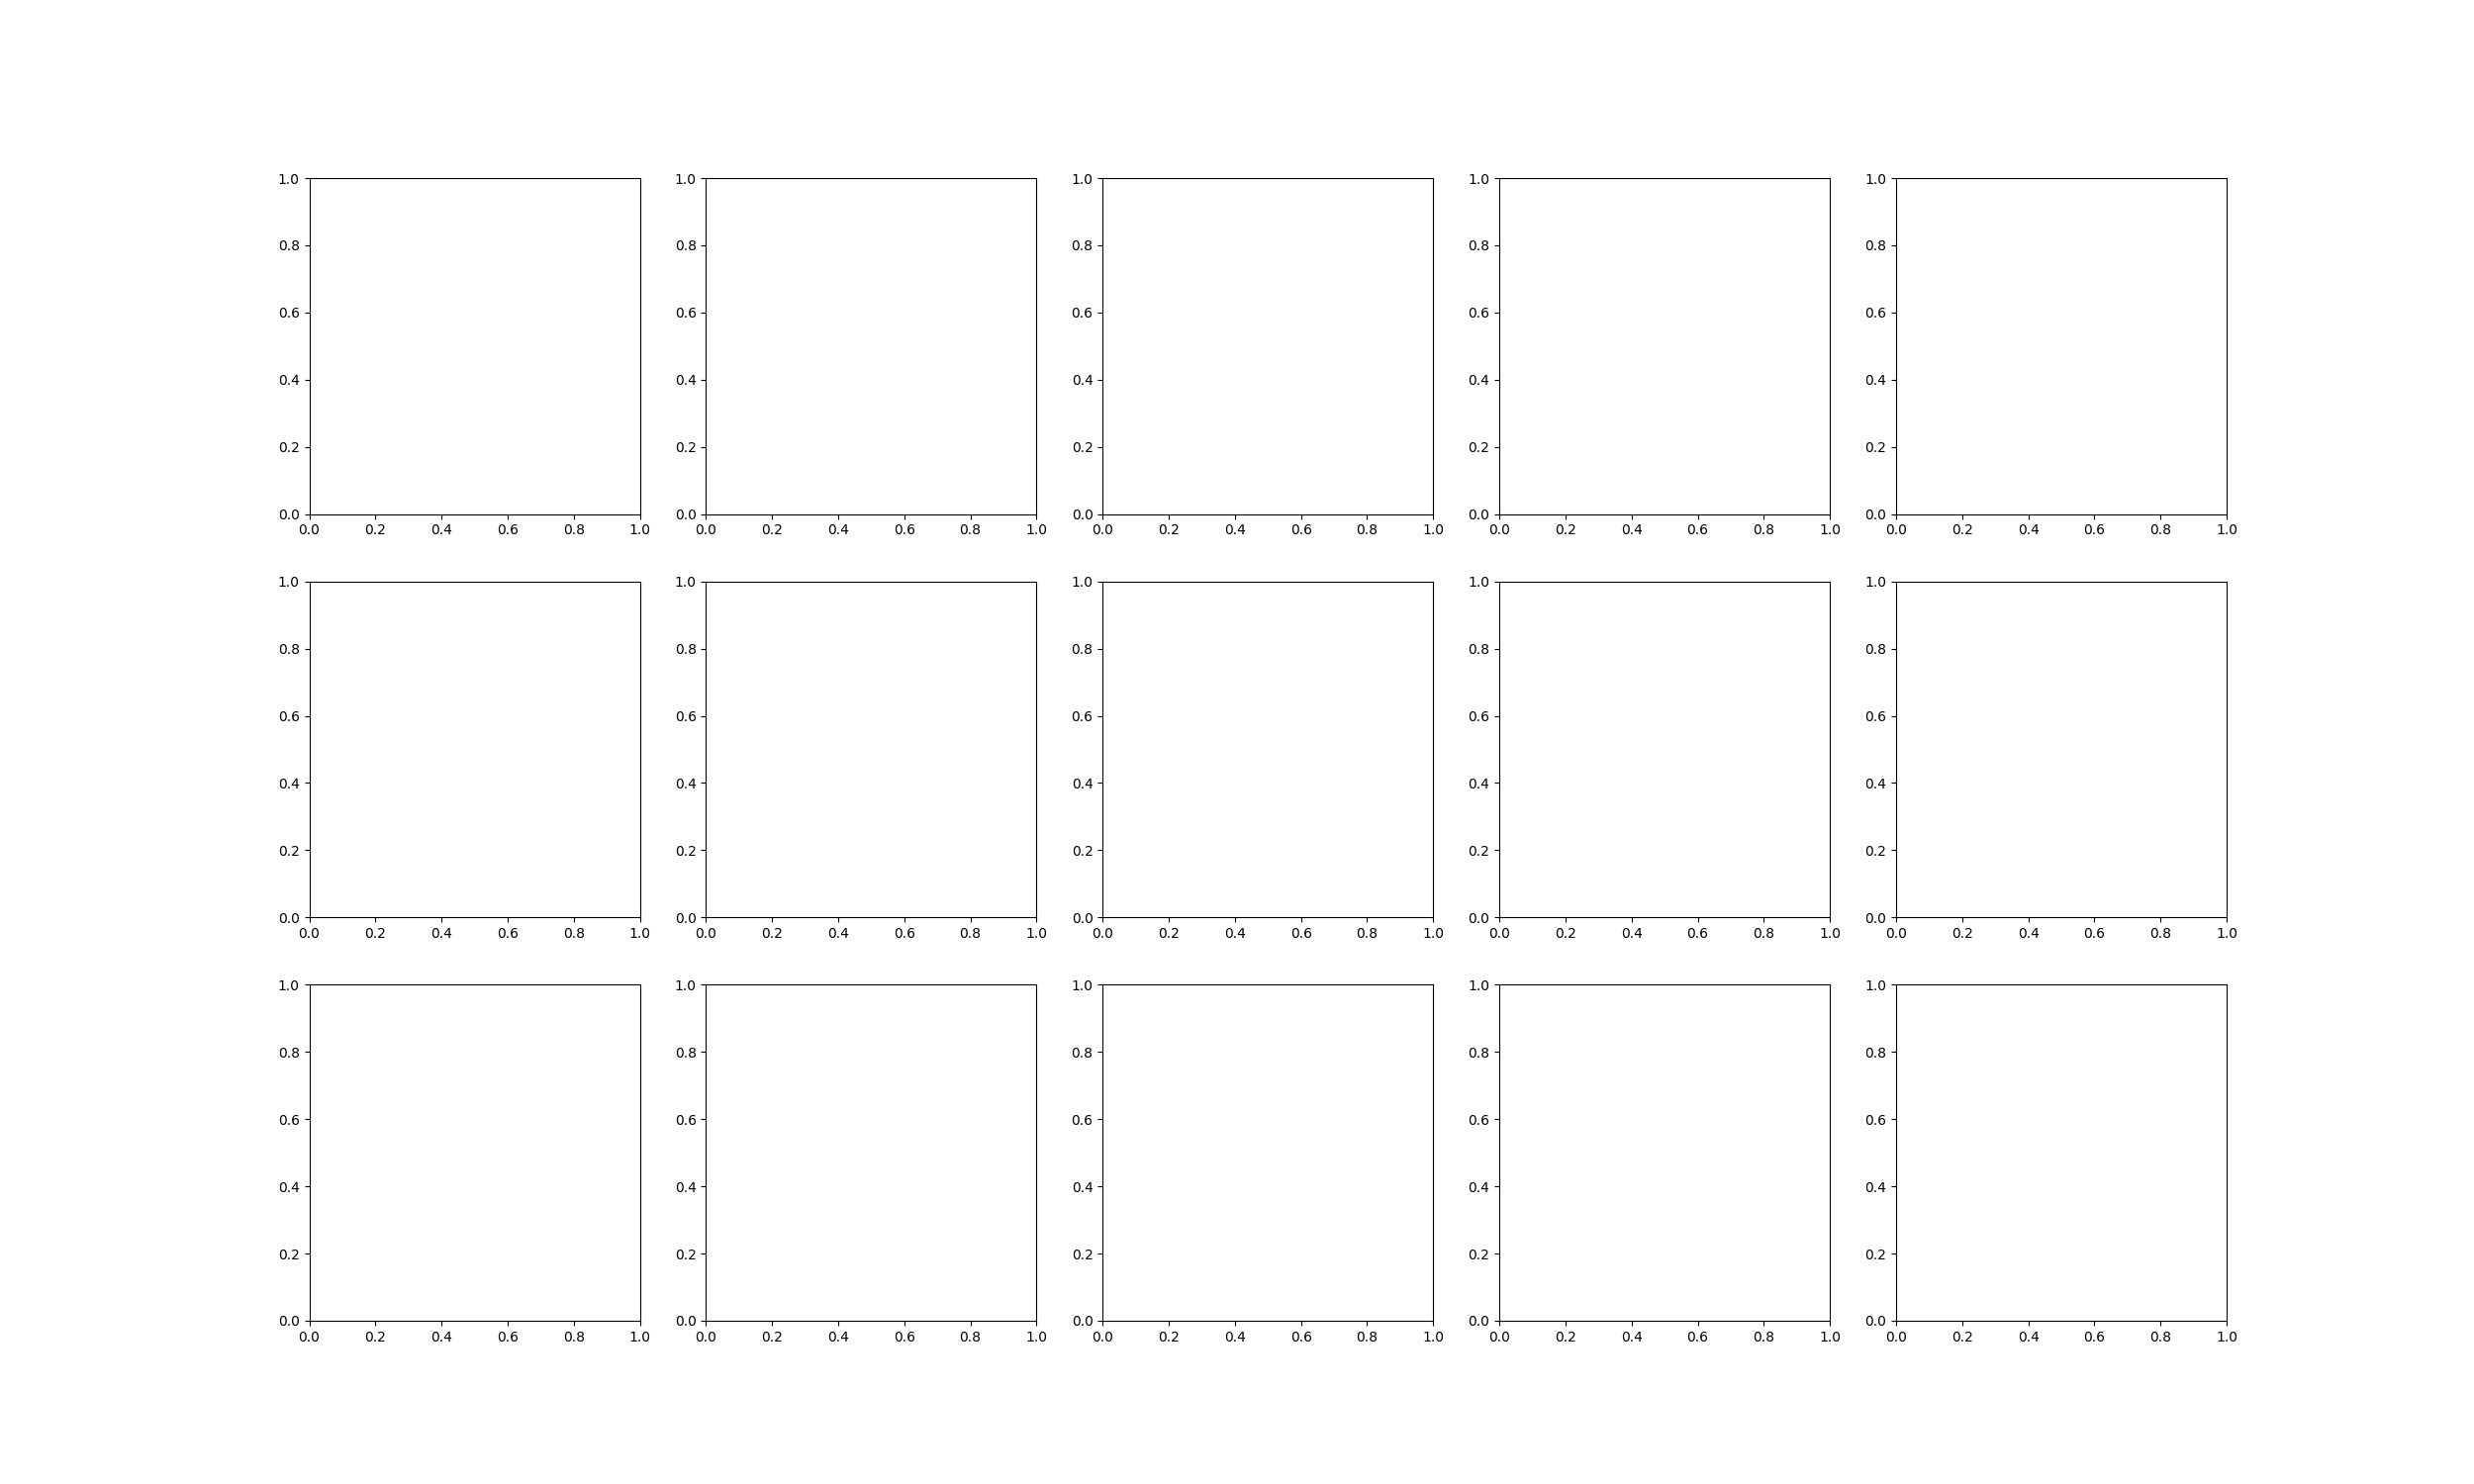

In [55]:
fig, axs = plt.subplots(3, n_plot_dissimilar//3, figsize=(25, 15))
interesting_vs = []

for ax, idx in zip(axs.flatten(), chosen_idxs):
    vg_vals = sorted_vg_vals[idx]
    mse = sorted_mse_vals[idx]

    # re-simulate with given configs
    for e, vg in zip(chain_net.edges, vg_vals):
        e.edge.parameters['val'] = vg

    chain_net._prepare_simulation(v_sweep_vals.reshape(-1, 1))
    res = chain_net._run_simulation()

    # hardcoded based on handmade network's output config
    out_vals = res.nodes['2'] - res.nodes['1']
    interesting_vs.append(out_vals)

    # re-compute MSE and ensure it matches
    assert np.isclose(quantify_nonlinearity(out_vals), mse), f"MSE mismatch: got {quantify_nonlinearity(out_vals)}, expected {mse}"

    ax.plot(v_sweep_vals, out_vals)
    ax.set_title(f"VG: {[f'{v:.2f}' for v in vg_vals]} MSE: {mse:.5f}")
    
fig.suptitle("Most Interesting Trials")
plt.show()

#### Try to train networks to reproduce these interesting examples

In [732]:
chain_net = TransistorNetworkGroundref("three chain", G_chain, node_cfg_chain, 'ngspice-subprocess')

In [733]:
train_examples = [np.array(aa) for aa in interesting_vs[:5]]
train_ground_truth = [sorted_vg_vals[i] for i in chosen_idxs[:5]]

In [734]:
# experimental setup
rng_seed_train = 0 # reproducible random initializations
N_ITERS = 1000
NUDGE_FACTOR = .5
LEARNING_RATE = 3
print("learning rate:", LEARNING_RATE)

v_sweep_vals = np.linspace(0, 1, 20) # same 20 points as before

learning rate: 3


In [735]:
preds = [[] for _ in range(5)]
labels = [[] for _ in range(5)]

In [736]:
# needed for training
e1, e2 = [], []
for E in chain_net.edges:
    a, b = list(map(int, E.edge.node_names[:2]))
    e1.append(a)
    e2.append(b)

# e1.pop(0)
# e2.pop(0)
e1, e2

([0, 1, 2], [1, 2, 3])

In [737]:
np.random.seed(rng_seed_train)

trial = 0 # hand-run each trial
in_data = v_sweep_vals.reshape(-1, 1)
out_data = train_examples[trial].reshape(-1, 1)

In [739]:
sd = .1
np.random.seed(rng_seed_train)

# randomly initialize network
for i, e in enumerate(chain_net.edges):
    # parameter name needs to be consistent with edge type
    # e.edge.parameters['val'] = 0.1
    # e.edge.parameters['val'] = train_ground_truth[trial][i] + np.random.uniform(-sd, sd)
    e.edge.parameters['val'] = train_ground_truth[trial][i] + sd
    # e.edge.parameters['val'] = np.random.uniform(0, 1)

chain_net.edges[0].edge.parameters['val'] = gt[0]

In [744]:
gt

[0.88, 0.35, 1.0]

In [740]:
print(chain_net)

.title three chain
.include /Users/lancemathias/Projects/circuit_sim/experiments/my_lib.lib
.subckt transistor_edge_groundref t_D t_S val=2.5
V1 t_G t_S {val}
X1 t_D t_G t_S 0 0 1106
.ends transistor_edge_groundref
B1 3 0
B2 2 1
Vindex index 0 1
X1 0 1 transistor_edge_groundref val=0.88
X2 1 2 transistor_edge_groundref val=0.44999999999999996
X3 2 3 transistor_edge_groundref val=1.1



In [745]:
old_edges = chain_net.edges[:]
# chain_net.edges.pop(0)

In [746]:
err_vals = []

In [747]:
grad_step = 1e-8 # finite difference step size

In [748]:
np.ones_like(chain_net.edges) * grad_step

array([1e-08, 1e-08, 1e-08], dtype=object)

In [749]:
opt_pts = []

# for j in tqdm.trange(N_ITERS, leave=False):
for j in tqdm.trange(N_ITERS, leave=False):
    # idx = np.random.randint(0, len(in_data))
    batch_update = np.zeros(3)
    abs_err = 0
    for idx in range(len(in_data)):
        grad = np.zeros(3)
        chain_net.update(np.ones(3) * grad_step)
        chain_net, pred, update = step_network(
            chain_net,
            in_data[idx],
            out_data[idx],
            e1, 
            e2,
            eta=NUDGE_FACTOR,
            gamma=LEARNING_RATE,
        )
        grad += pred.squeeze()
        chain_net.update(-2 * np.ones(3) * grad_step)
        chain_net, pred, update = step_network(
            chain_net,
            in_data[idx],
            out_data[idx],
            e1, 
            e2,
            eta=NUDGE_FACTOR,
            gamma=LEARNING_RATE,
        )
        grad -= pred.squeeze()
        grad /= 2 * grad_step
        chain_net.update(np.ones(3) * grad_step) # reset back to how it was

        abs_err += np.abs(out_data[idx].item() - pred.item())
        batch_update += grad
        # batch_update += update

    chain_net.update(batch_update / len(in_data))
    # chain_net, pred, update = step_network(
    #     chain_net,
    #     in_data[idx],
    #     out_data[idx],
    #     e1, 
    #     e2,
    #     eta=NUDGE_FACTOR,
    #     gamma=LEARNING_RATE,
    # )
    # labels[trial].append(out_data[idx].item())
    # preds[trial].append(pred.item())
    err_vals.append(abs_err/len(in_data))
    opt_pts.append([e.edge.parameters['val'] for e in old_edges])

KeyboardInterrupt: 

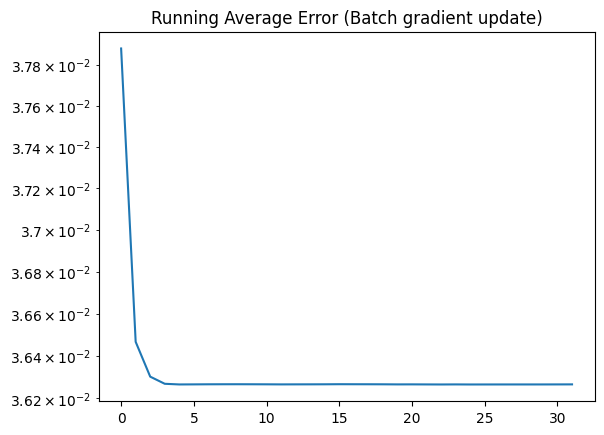

In [731]:
# running average error
running_avg_err = np.convolve(err_vals, np.ones(20)/20, mode='valid')

plt.semilogy(running_avg_err)
plt.title("Running Average Error (Batch gradient update)")
plt.show()

In [ ]:
upda

In [728]:
# running average error
abs_err = np.abs(np.array(preds[trial]) - np.array(labels[trial]))
running_avg_err = np.convolve(abs_err, np.ones(20)/20, mode='valid')

plt.semilogy(running_avg_err)
plt.title("Running Average Error")
plt.show()

ValueError: v cannot be empty

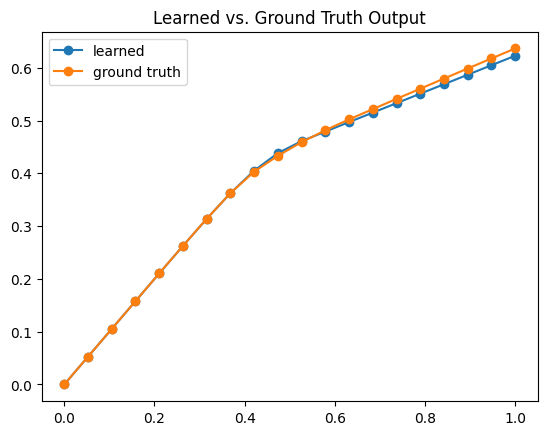

In [761]:
chain_net._prepare_simulation(v_sweep_vals.reshape(-1, 1))
res = chain_net._run_simulation()

# hardcoded based on handmade network's output config
out_vals = res.nodes['2'] - res.nodes['1']


plt.plot(v_sweep_vals, out_vals, '-o', label='learned')
plt.plot(v_sweep_vals, train_examples[trial], '-o', label='ground truth')
plt.legend()
plt.title("Learned vs. Ground Truth Output")
plt.show()

In [576]:
[e.edge.parameters['val'] for e in chain_net.edges], train_ground_truth[trial]

([0.48293140997784945, 0.20578176543297616, 0.980237756453446],
 [0.88, 0.35, 1.0])

In [514]:
out_vals

WaveForm  [-1.16351373e-13  5.26251723e-02  1.05242964e-01  1.57830885e-01
  2.10323788e-01  2.62515776e-01  3.13770366e-01  3.62384303e-01
  4.02731358e-01  4.33162072e-01  4.59069811e-01  4.81916463e-01
  5.02663983e-01  5.22112230e-01  5.41537091e-01  5.60804008e-01
  5.79973695e-01  5.99056160e-01  6.18059401e-01  6.36990504e-01]@V

In [480]:
# v2 fixed
chain_net.edges[1].edge.parameters['val'] = .35

err_grid = []

v1_range = np.linspace(.83, .86, 100)
v2_range = np.linspace(1., 1.08, 40)

for v1 in v1_range:
    chain_net.edges[0].edge.parameters['val'] = v1
    err_grid.append([])
    for v2 in v2_range:
        chain_net.edges[2].edge.parameters['val'] = v2
        chain_net._prepare_simulation(v_sweep_vals.reshape(-1, 1))
        res = chain_net._run_simulation()
        out_vals = res.nodes['2'] - res.nodes['1']
        err = np.mean(np.abs(np.array(out_vals) - train_examples[trial]))
        err_grid[-1].append(err)

IndexError: list index out of range

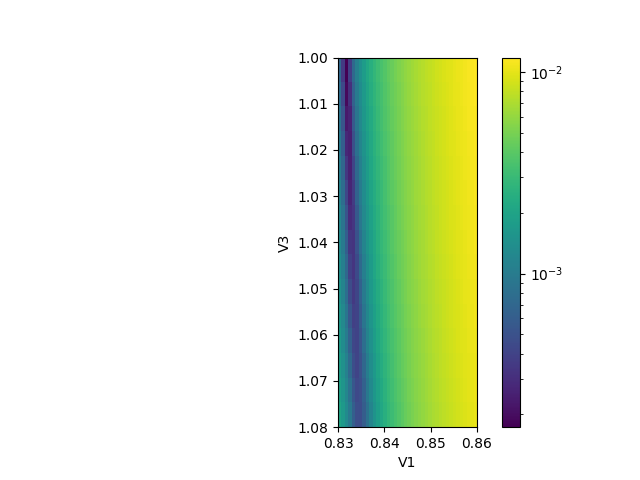

In [121]:
%matplotlib widget
# reset plt
plt.close()
plt.imshow(err_grid, norm='log', 
           extent=(v1_range.min(), v1_range.max(), v2_range.max(), v2_range.min()), 
           origin='lower', interpolation='none')
plt.xlabel('V1')
plt.ylabel('V3')
plt.colorbar()
plt.show()

#### Plot 3d surfaces
Each slice is taken by fixing the ground truth voltage for 1 edge and varying the other 2

In [439]:
N_PTS = 27
SWEEP_RANGE = .3 # +- initial value to sweep
# SWEEP_PERCENT = .2 # plot initial value +- 20% of initial value - used to replace fixed range

gt = [0.88, 0.35, 1.]
inputs = np.array([2.09832152e-14, 5.26253216e-02, 1.05243419e-01, 1.57832267e-01,
        2.10327927e-01, 2.62527799e-01, 3.13799413e-01, 3.62445055e-01,
        4.02960024e-01, 4.33255762e-01, 4.58973287e-01, 4.81624397e-01,
        5.02194694e-01, 5.21598820e-01, 5.41020734e-01, 5.60299491e-01,
        5.79480034e-01, 5.98572527e-01, 6.17585055e-01, 6.36524779e-01])
# sweep_ranges = [np.linspace(gt[i] * (1-SWEEP_PERCENT), gt[i] * (1+SWEEP_PERCENT), N_PTS) for i in range(3)]
sweep_ranges = [np.linspace(gt[i] - SWEEP_RANGE, gt[i] + SWEEP_RANGE, N_PTS) for i in range(3)]


In [440]:
sweep_ranges

[array([0.58      , 0.60307692, 0.62615385, 0.64923077, 0.67230769,
        0.69538462, 0.71846154, 0.74153846, 0.76461538, 0.78769231,
        0.81076923, 0.83384615, 0.85692308, 0.88      , 0.90307692,
        0.92615385, 0.94923077, 0.97230769, 0.99538462, 1.01846154,
        1.04153846, 1.06461538, 1.08769231, 1.11076923, 1.13384615,
        1.15692308, 1.18      ]),
 array([0.05      , 0.07307692, 0.09615385, 0.11923077, 0.14230769,
        0.16538462, 0.18846154, 0.21153846, 0.23461538, 0.25769231,
        0.28076923, 0.30384615, 0.32692308, 0.35      , 0.37307692,
        0.39615385, 0.41923077, 0.44230769, 0.46538462, 0.48846154,
        0.51153846, 0.53461538, 0.55769231, 0.58076923, 0.60384615,
        0.62692308, 0.65      ]),
 array([0.7       , 0.72307692, 0.74615385, 0.76923077, 0.79230769,
        0.81538462, 0.83846154, 0.86153846, 0.88461538, 0.90769231,
        0.93076923, 0.95384615, 0.97692308, 1.        , 1.02307692,
        1.04615385, 1.06923077, 1.09230769, 1.11

In [ ]:
# planes = []

with tqdm.tqdm(total=3*N_PTS**2) as pbar:
    for i in range(3):
        chain_net.edges[i].edge.parameters['val'] = gt[i]
        this_plane = []
        vary1 = (i+1)%3
        for v1 in sweep_ranges[vary1]:
            chain_net.edges[vary1].edge.parameters['val'] = v1
            this_plane.append([])
            vary2 = (i+2)%3
            for v2 in sweep_ranges[vary2]:
                chain_net.edges[vary2].edge.parameters['val'] = v2
                chain_net._prepare_simulation(v_sweep_vals.reshape(-1, 1))
                res = chain_net._run_simulation()
                out_vals = res.nodes['2'] - res.nodes['1']
                err = np.mean(np.abs(np.array(out_vals) - inputs))
                pbar.update(1)
                this_plane[-1].append(err)
                print([e.get_val() for e in chain_net.edges])
        # planes.append(this_plane)
# with tqdm.tqdm(total=N_PTS**3) as pbar:
#     for v0 in sweep_ranges[0]:
#         chain_net.edges[0].edge.parameters['val'] = v0
#         for v1 in sweep_ranges[1]:
#             chain_net.edges[1].edge.parameters['val'] = v1
#             for v2 in sweep_ranges[2]:
#                 chain_net.edges[2].edge.parameters['val'] = v2
#                 chain_net._prepare_simulation(v_sweep_vals.reshape(-1, 1))
#                 res = chain_net._run_simulation()
#                 out_vals = res.nodes['2'] - res.nodes['1']
#                 err = np.mean(np.abs(np.array(out_vals) - inputs))
#                 pbar.update(1)
#                 planes.append(err)

In [375]:
coords = [(i, j, k) for i in sweep_ranges[0] for j in sweep_ranges[1] for k in sweep_ranges[2]]

In [376]:
X, Y = np.meshgrid(sweep_ranges[0], sweep_ranges[1])
Z, _ = np.meshgrid(sweep_ranges[2], sweep_ranges[0])
ONES = np.ones_like(X)

In [377]:
# np.savez('planes.npz', planes=planes, sweep_ranges=sweep_ranges)
planes = np.load('planes.npz')['planes']
sweep_ranges = np.load('planes.npz')['sweep_ranges']

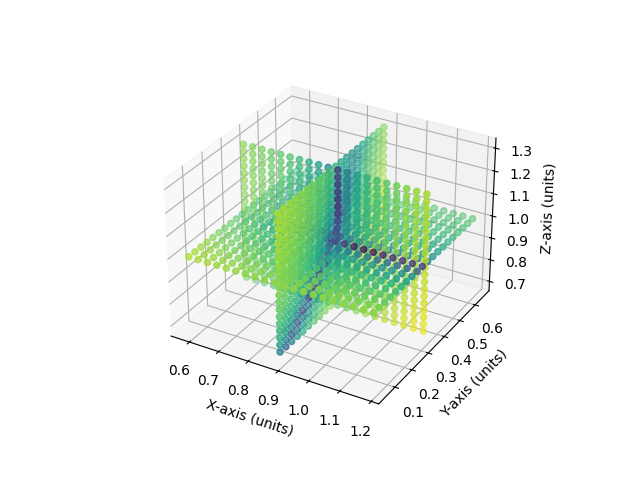

In [342]:
%matplotlib widget
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

norm = matplotlib.colors.LogNorm(vmin=np.min(planes), vmax=np.max(planes))
cmap = plt.cm.viridis

idxs = [
    (ONES*gt[0], Y, Z),
    (X, Y, ONES*gt[2]),
    (X, ONES*gt[1], Z.T),
]

ax.scatter(*np.concatenate(idxs, axis=-1), c=np.concatenate(planes, axis=-1), cmap=cmap, norm=norm)
# for i, iis in enumerate(idxs):
#     ax.plot_surface(*iis, rstride=1, cstride=1, facecolors=cmap(planes[i]), norm=norm, shade=True)  # XY plane
#     ax.scatter(*iis, c=planes[i], cmap=cmap, norm=norm)

ax.set_xlabel("X-axis (units)")
ax.set_ylabel("Y-axis (units)")
ax.set_zlabel("Z-axis (units)")

# fig.colorbar(surface, ax=ax, shrink=0.5, aspect=5)

plt.show()

In [402]:
np.min(planes, axis=(1, 2))

array([0.00064621, 0.00026779, 0.00055356])

In [647]:
opt_pts

array([[ 1.15633969, -0.92462395,  1.41375834],
       [ 1.0726669 ,  4.07021089,  1.28984333],
       [ 3.92050114,  0.71672178,  3.49615993],
       [ 3.82585211,  2.49711166,  3.34746302],
       [ 4.45478348, -0.77047302,  4.28893326],
       [ 4.36479941,  4.22436187,  4.17272013],
       [ 5.41277502,  0.58082407,  5.42574442],
       [ 5.28470677,  3.76628676,  5.28109676],
       [ 6.07845181,  0.4334468 ,  6.13633457],
       [ 5.95431814,  4.32268392,  6.00008174],
       [ 6.77974844,  0.96145829,  6.86650547],
       [ 6.66416186,  2.80713974,  6.74245899],
       [ 7.03202306,  0.45616491,  7.1247765 ],
       [ 6.90721944,  4.39624453,  6.9910878 ],
       [ 7.62682435,  1.20159014,  7.73394541],
       [ 7.53677101,  2.31189365,  7.63842714],
       [ 7.70747134,  0.82149038,  7.81371692],
       [ 7.57719761,  3.51334127,  7.67591622],
       [ 8.0376202 ,  0.88432796,  8.14919605],
       [ 7.90909983,  3.38595171,  8.01379119],
       [ 8.31303292,  0.9258449 ,  8.428

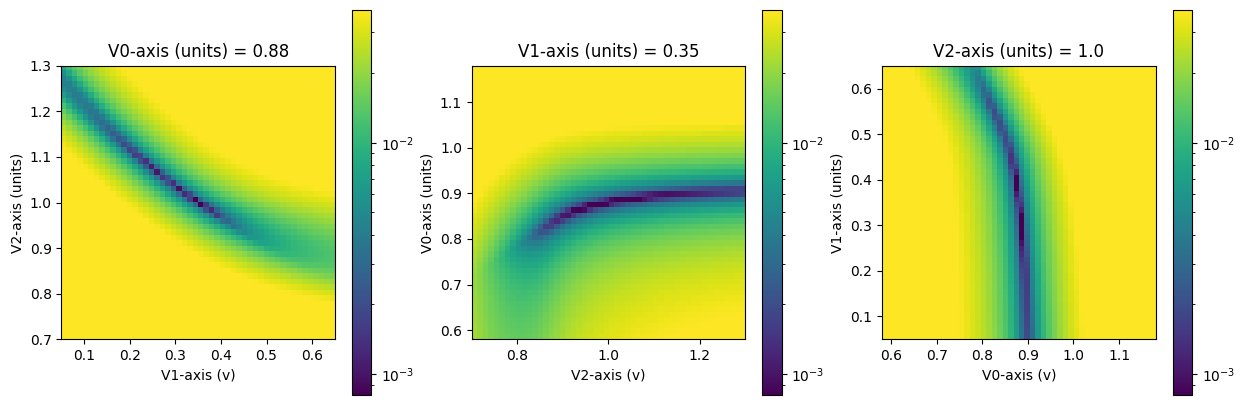

In [763]:
%matplotlib inline
plt.close()
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

opt_pts = np.array(opt_pts)

for i, pp in enumerate(planes):
    ax = axs[i]
    vary1 = (i+1)%3
    vary2 = (i+2)%3
    # vary point color; later is darker
    # [x_min, x_max, y_min, y_max]
    # im = ax.imshow(pp, cmap=cmap, extent=(sweep_ranges[vary1][0], sweep_ranges[vary1][-1], sweep_ranges[vary2][0], sweep_ranges[vary2][-1]), origin='lower')
    
    # ax.scatter(opt_pts[:, vary1], opt_pts[:, vary2], s=.5, c=np.arange(len(opt_pts)), cmap='viridis', )
    # ax.contourf(X, Y, pp, norm=norm, cmap=cmap, levels=1)
    ax.set_xlabel(f"V{vary1}-axis (v)")
    ax.set_ylabel(f"V{vary2}-axis (units)")
    ax.set_title(f"V{i}-axis (units) = {gt[i]}")
    plt.colorbar(im)
plt.show()

In [133]:
len(planes)

8000

In [135]:
len(coords)

8000

In [141]:
plot_thresh = 5e-2
coords_plot = np.array(coords)[np.array(planes) < plot_thresh]
planes_plot = np.array(planes)[np.array(planes) < plot_thresh]

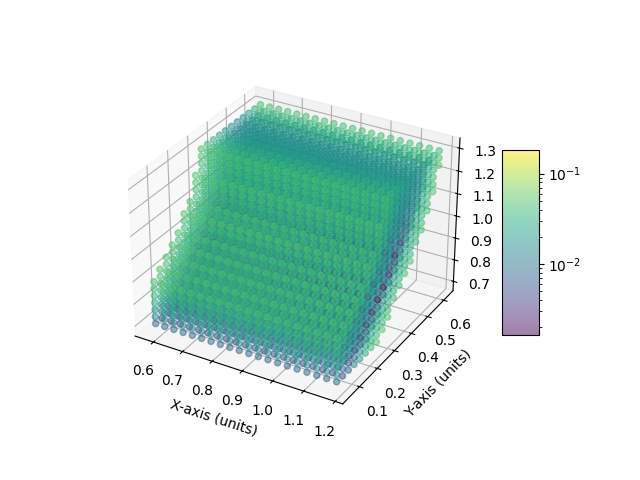

In [143]:
%matplotlib widget
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

norm = matplotlib.colors.LogNorm(vmin=np.min(planes), vmax=np.max(planes))
cmap = plt.cm.viridis

pp = ax.scatter(*np.transpose(coords_plot), c=planes_plot, cmap=cmap, norm=norm, alpha=0.5)
# pp = ax.scatter(*np.transpose(coords), c=planes, cmap=cmap, norm=norm, alpha=0.5)
# for i, iis in enumerate(idxs):
#     ax.plot_surface(*iis, rstride=1, cstride=1, facecolors=cmap(planes[i]), norm=norm, shade=True)  # XY plane
#     ax.scatter(*iis, c=planes[i], cmap=cmap, norm=norm)

ax.set_xlabel("X-axis (units)")
ax.set_ylabel("Y-axis (units)")
ax.set_zlabel("Z-axis (units)")

fig.colorbar(pp, ax=ax, shrink=0.5, aspect=5)

plt.show()

In [ ]:
flat_idxs = np.array(coords_plot)

In [305]:
import numpy as np
import plotly.graph_objects as go

x, y, z = np.transpose(coords)
# values = np.log(planes)
values = planes

# Create 3D scatter plot
fig = go.Figure(
    data=go.Scatter3d(
        x=x, y=y, z=z,
        mode='markers',
        marker=dict(
            size=5,
            color=values,  # Values for color mapping
            colorscale='Viridis',  # Color scale
            colorbar=dict(title='Intensity'),
            opacity=0.5,
            # opacity=1,
        )
    )
)

# Customize layout
fig.update_layout(scene=dict(
    xaxis_title="X-axis",
    yaxis_title="Y-axis",
    zaxis_title="Z-axis"
))

fig.show()

In [301]:
import numpy as np
import plotly.graph_objects as go

x, y, z = np.transpose(coords)
values = np.log(planes)

sweep_idx = 1 # 0, 1, or 2
z_values = sweep_ranges[sweep_idx]
z_min, z_max = np.min(z_values), np.max(z_values)
frames = []
steps = []

for i, z_value in enumerate(z_values):
    visible_points = np.isclose(np.transpose(coords)[sweep_idx], z_value)
    frames.append(go.Frame(
        data=[go.Heatmap(
            x=x[visible_points],
            y=y[visible_points],
            z=values[visible_points],
        )],
        name=f"slice_{z_value:.2f}"
    ))
    step = {
        'args': [
            [z_value],
            {'frame': {'duration': 300, 'redraw': True}},
        ],
        'label': f'Slice at {z_value:.2f}',
        'method': 'relayout',
    }
    steps.append(step)

fig = go.Figure(
    data=[go.Heatmap(
        x=x,
        y=y,
        z=values,
    )],
    frames=frames
)

fig.update_layout(
    sliders=[{
        'currentvalue': {
            'font': {'size': 20},
            'prefix': 'Z Slice: ',
            'visible': True,
        },
        'steps': steps
    }],
    xaxis_title="X-axis",
    yaxis_title="Y-axis"
)

fig.show()

In [236]:
sweep_ranges[sweep_idx+1]

array([0.05      , 0.08157895, 0.11315789, 0.14473684, 0.17631579,
       0.20789474, 0.23947368, 0.27105263, 0.30263158, 0.33421053,
       0.36578947, 0.39736842, 0.42894737, 0.46052632, 0.49210526,
       0.52368421, 0.55526316, 0.58684211, 0.61842105, 0.65      ])

In [233]:
visible_points.sum()

0

In [286]:
import numpy as np
import plotly.graph_objects as go

sweep_idx = 2  # 0, 1, or 2
other_idxs = [i for i in range(3) if i != sweep_idx]
x, y = np.transpose(coords)[other_idxs]
z = np.transpose(coords)[sweep_idx]
values = np.log(planes)
z_values = z
z_min, z_max = np.min(z_values), np.max(z_values)
frames = []
steps = []

# Create figure
fig = go.Figure()

# Add traces, one for each slider step
for step in sweep_ranges[sweep_idx]:
    visible_points = np.isclose(z, step)
    fig.add_trace(
        go.Heatmap(
            x=x[visible_points],
            y=y[visible_points],
            z=values[visible_points],
            name=f"Slice at {step:.2f}",
            visible=False,
            coloraxis='coloraxis'
        )
    )

fig.data[0].visible = True

# Create and add slider
steps = []
for i in range(len(fig.data)):
    step = dict(
        method="update",
        args=[{"visible": [False] * len(fig.data)},]
            #   {"title": "Slider switched to step: " + str(i)}],  # layout attribute
    )
    step["args"][0]["visible"][i] = True  # Toggle i'th trace to "visible"
    steps.append(step)

sliders = [dict(
    active=10,
    currentvalue={"prefix": f"V{sweep_idx + 1}: "},
    pad={"t": 50},
    steps=steps
)]

fig.update_layout(
    sliders=sliders,
    coloraxis = dict(
        colorbar=dict(title="Log error",),
        cmin=np.min(values), 
        cmax=np.max(values),
        ),
)

fig.show()


TypeError: Invalid shape () for image data

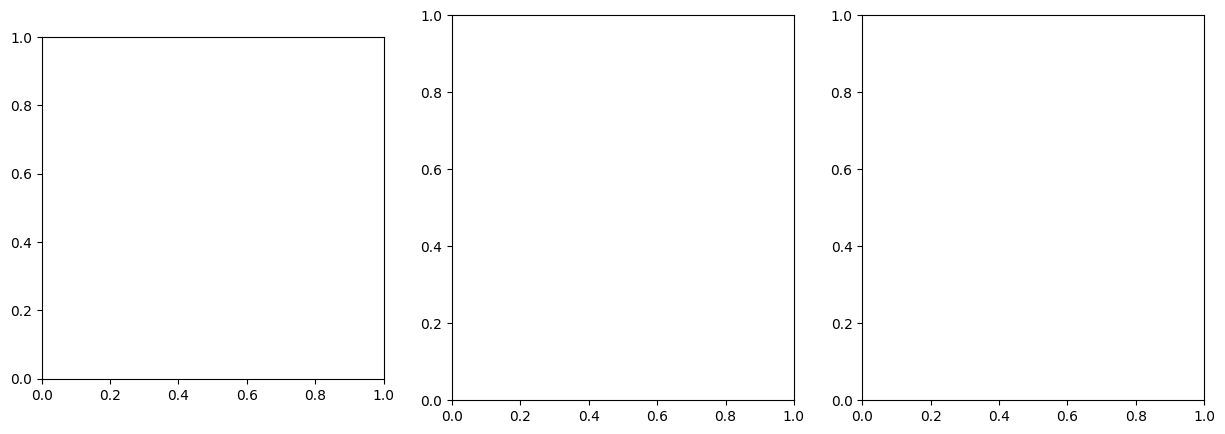

In [185]:
%matplotlib inline
plt.close()
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs[0].imshow(planes[0], 
              cmap='viridis', norm=norm, interpolation='none', extent=[sweep_ranges[1][0], sweep_ranges[1][-1], sweep_ranges[2][-1], sweep_ranges[2][0]])
axs[0].set_title(f"Fixing VG1={gt[0]}")
axs[0].set_xlabel("VG2")
axs[0].set_ylabel("VG3")
axs[1].imshow(planes[1], cmap='viridis', norm=norm, interpolation='none', extent=[sweep_ranges[0][0], sweep_ranges[0][-1], sweep_ranges[2][-1], sweep_ranges[2][0]])
axs[1].set_title(f"Fixing VG2={gt[1]}")
axs[1].set_xlabel("VG1")
axs[1].set_ylabel("VG3")
axs[2].imshow(planes[2], cmap='viridis', norm=norm, interpolation='none', extent=[sweep_ranges[0][0], sweep_ranges[0][-1], sweep_ranges[1][-1], sweep_ranges[1][0]])
axs[2].set_title(f"Fixing VG3={gt[2]}")
axs[2].set_xlabel("VG1")
axs[2].set_ylabel("VG2")

plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap='viridis'), ax=axs)
plt.show()

In [28]:
gt

[0.88, 0.35, 1.0]